In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from utils.constants import chamber_levels

In [ ]:
# observed values, separately for hummock and hollow
obs_frac = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 'Tip_colonization_data_2017.csv'),
                       na_values = -9999)
obs_frac = obs_frac[['microtopography', 'plot', 'larch_and_spruce_colonization_percent']]
obs_frac['larch_and_spruce_colonization_percent'] /= 100.0
obs_frac['temperature'] = [chamber_levels[f'{plot:02d}'][0] for plot in obs_frac['plot']]
obs_frac['co2'] = [chamber_levels[f'{plot:02d}'][1] for plot in obs_frac['plot']]
obs_frac = obs_frac.dropna(subset = 'larch_and_spruce_colonization_percent').set_index(['microtopography', 'temperature', 'co2', 'plot'])

In [ ]:
obs_frac_avg = obs_frac.loc['hummock'] * 0.64 + obs_frac.loc['hollow'] * 0.36
obs_frac_avg

larch_and_spruce_colonization_percent
temperature co2 plot                                       
0.00        0   6                                       NaN
            500 19                                      NaN
2.25        0   20                                 0.411024
            500 11                                 0.621866
4.50        0   13                                 0.198257
            500 4                                  0.697707
6.75        0   8                                  0.507043
            500 16                                 0.362690
9.00        0   17                                 0.107080
            500 10                                      NaN

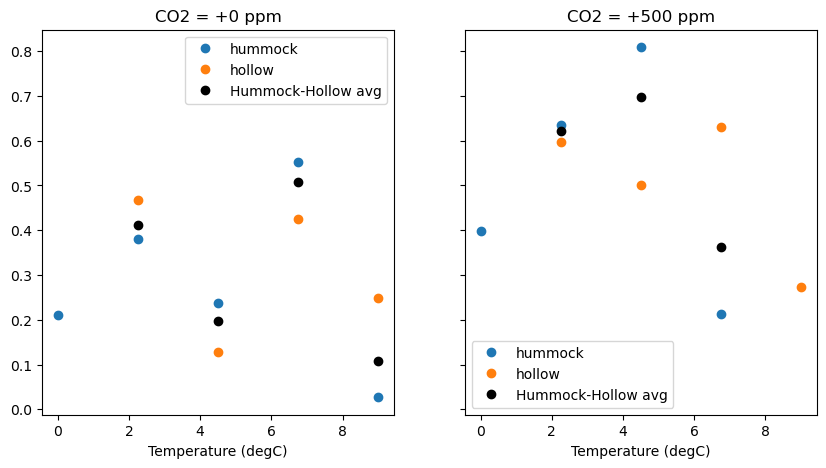

In [4]:
fig, axes = plt.subplots(1, 2, figsize = (10, 5), sharey = True)
for i, co2 in enumerate([0, 500]):
    ax = axes[i]
    for top in ['hummock', 'hollow']:
        ax.plot(obs_frac.loc[(top, slice(None), co2)].reset_index()['temperature'], 
                obs_frac.loc[(top, slice(None), co2)].reset_index()['larch_and_spruce_colonization_percent'], 'o', label = top)

    ax.plot(obs_frac_avg.loc[(slice(None), co2), :].reset_index()['temperature'],
            obs_frac_avg.loc[(slice(None), co2), :].reset_index()['larch_and_spruce_colonization_percent'], 'ok', label = f'Hummock-Hollow avg')

    ax.legend()
    ax.set_title(f'CO2 = +{co2} ppm')
    ax.set_xlabel('Temperature (degC)')